In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [ ]:
df = pd.read_csv(r"C:\Users\User\Desktop\E81\archive (1)\US_Accidents_March23.csv")
print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [ ]:
# Select required columns
df = df[['Start_Time', 'Weather_Condition', 'Start_Lat', 'Start_Lng']]

# Drop missing values
df = df.dropna()

# Fix datetime conversion
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')

# Drop invalid converted rows
df = df.dropna(subset=['Start_Time'])

# Extract hour
df['Hour'] = df['Start_Time'].dt.hour

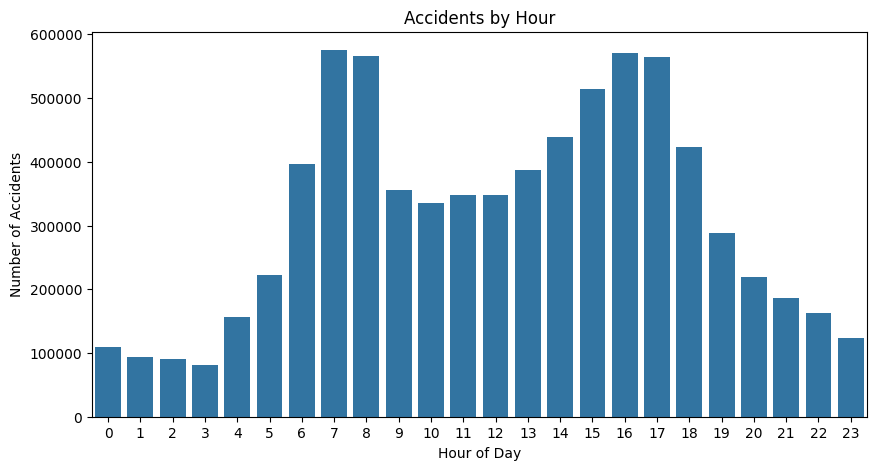

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df)
plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

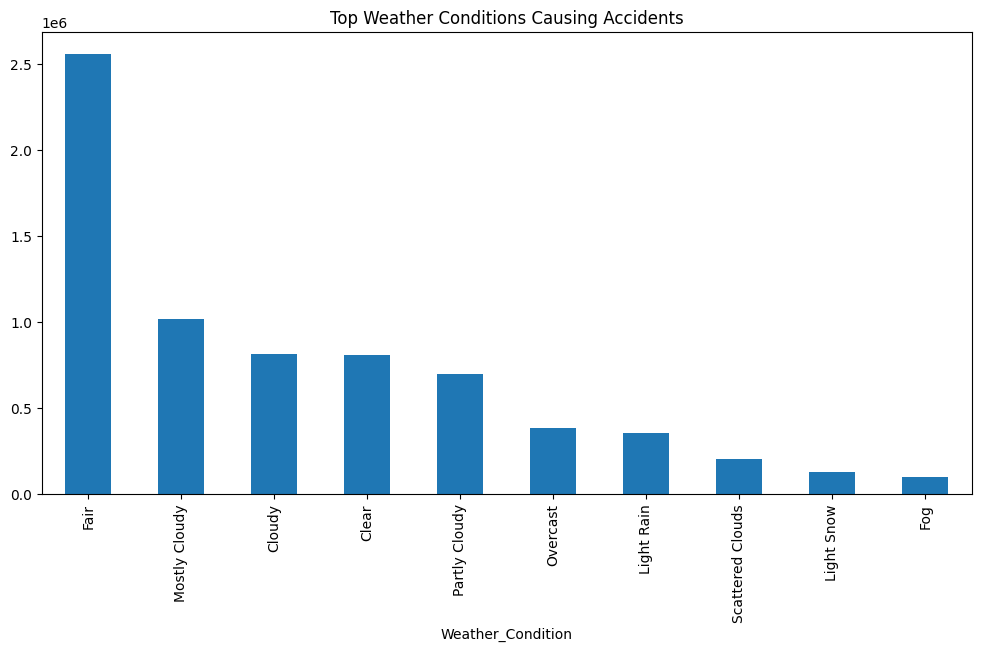

In [ ]:
plt.figure(figsize=(12,6))
df['Weather_Condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top Weather Conditions Causing Accidents")
plt.show()

In [ ]:
import pandas as pd
import folium



# Select required columns
df = df[['Start_Lat', 'Start_Lng']].dropna()

# Take sample (important for performance)
df_sample = df.sample(2000, random_state=42)

# Create map
m = folium.Map(
    location=[df_sample['Start_Lat'].mean(), df_sample['Start_Lng'].mean()],
    zoom_start=5
)

# Add points
for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['Start_Lat'], row['Start_Lng']],
        radius=2,
        color='red',
        fill=True
    ).add_to(m)

# ✅ DISPLAY MAP IN JUPYTER
m

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap




# Select required columns
df = df[['Start_Lat', 'Start_Lng']].dropna()

# Take sample (important for speed)
df_sample = df.sample(3000, random_state=42)

# Create base map
m = folium.Map(
    location=[df_sample['Start_Lat'].mean(), df_sample['Start_Lng'].mean()],
    zoom_start=5
)

# Prepare heatmap data
heat_data = df_sample[['Start_Lat', 'Start_Lng']].values.tolist()

# Add heatmap
HeatMap(heat_data).add_to(m)

# ✅ Show in Jupyter
m